# 🧠 Section 02. 대표 CNN 아키텍처의 진화
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- LeNet-5 / AlexNet / VGGNet / ResNet을 torchvision에서 로드하고 구조를 분석한다
- 각 아키텍처의 파라미터 수를 비교하고 시각화한다
- ResNet의 핵심 아이디어인 ResidualBlock을 직접 구현한다
- 더미 입력으로 각 모델의 forward pass를 검증한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | 없음 (모델 구조 분석) |
| 크기 | 더미 텐서 사용 |
| 클래스 | 해당 없음 |
| 출처 | `torchvision.models` 사전 정의 모델 |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

**환경이 아직 설정되지 않았다면:**
```bash
conda env create -f environment.yml
conda activate cnn-course
```

**Jupyter Lab 실행:**
```bash
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다. CPU만 있어도 실습에 지장 없습니다.

In [1]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ torchvision 버전: {torchvision.__version__}")

✅ 사용 디바이스: cpu
✅ PyTorch 버전: 2.11.0+cpu
✅ torchvision 버전: 0.26.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


## 📁 실습 개요

이번 실습은 `torchvision.models`에 내장된 사전 정의 모델을 활용합니다.

| 모델 | torchvision 코드 | 특징 |
|------|-----------------|------|
| LeNet-5 | 직접 구현 | 가장 단순한 구조 |
| AlexNet | `models.alexnet()` | 최초 GPU 학습 모델 |
| VGG-16 | `models.vgg16()` | 3×3 필터 통일 |
| ResNet-50 | `models.resnet50()` | Residual Connection |

> ⚠️ 이번 실습은 **가중치 다운로드 없이** 구조 분석만 합니다.  
> `pretrained=True` 대신 `weights=None`을 사용합니다.

---
## 실습 1. LeNet-5 — 직접 구현 및 구조 확인

In [3]:
# ─────────────────────────────────────────────
# 1-1. LeNet-5 구현
# ─────────────────────────────────────────────

class LeNet5(nn.Module):
    """
    LeNet-5 구현 (1998, LeCun et al.)
    입력: (N, 1, 32, 32) → 출력: (N, 10)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),       # (1,32,32)→(6,28,28)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # (6,28,28)→(6,14,14)
            nn.Conv2d(6, 16, kernel_size=5),       # (6,14,14)→(16,10,10)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # (16,10,10)→(16,5,5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),           # Flatten→FC
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

lenet = LeNet5()
print("=== LeNet-5 구조 ===")
print(lenet)

total = sum(p.numel() for p in lenet.parameters())
print(f"\n총 파라미터 수: {total:,}")

=== LeNet-5 구조 ===
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Tanh()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

총 파라미터 수: 61,706


In [4]:
# ─────────────────────────────────────────────
# 1-2. LeNet-5 forward pass 검증
# ─────────────────────────────────────────────

dummy_lenet = torch.randn(4, 1, 32, 32)
out_lenet = lenet(dummy_lenet)
print(f"입력: {dummy_lenet.shape} → 출력: {out_lenet.shape}")
assert out_lenet.shape == (4, 10), "shape 불일치!"
print("✅ Forward pass 성공!")

입력: torch.Size([4, 1, 32, 32]) → 출력: torch.Size([4, 10])
✅ Forward pass 성공!


---
## 실습 2. AlexNet / VGG-16 / ResNet-50 구조 로드

In [5]:
# ─────────────────────────────────────────────
# 2-1. 모델 로드 (가중치 없이 구조만)
# ─────────────────────────────────────────────
# weights=None: 사전학습 가중치 없이 구조만 초기화

alexnet = models.alexnet(weights=None)
vgg16   = models.vgg16(weights=None)
resnet50 = models.resnet50(weights=None)

print("✅ 모델 로드 완료 (가중치 없음 — 구조 분석용)")
print(f"  AlexNet  파라미터: {sum(p.numel() for p in alexnet.parameters()):>12,}")
print(f"  VGG-16   파라미터: {sum(p.numel() for p in vgg16.parameters()):>12,}")
print(f"  ResNet50 파라미터: {sum(p.numel() for p in resnet50.parameters()):>12,}")

✅ 모델 로드 완료 (가중치 없음 — 구조 분석용)
  AlexNet  파라미터:   61,100,840
  VGG-16   파라미터:  138,357,544
  ResNet50 파라미터:   25,557,032


In [6]:
# ─────────────────────────────────────────────
# 2-2. AlexNet 구조 출력 및 분석
# ─────────────────────────────────────────────

print("=== AlexNet 구조 ===")
print(alexnet)
print()

# features / classifier 분리 구조 확인
print("--- features 레이어 ---")
for i, layer in enumerate(alexnet.features):
    print(f"  [{i}] {type(layer).__name__}")

print("\n--- classifier 레이어 ---")
for i, layer in enumerate(alexnet.classifier):
    print(f"  [{i}] {type(layer).__name__}")

=== AlexNet 구조 ===
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features

In [ ]:
# ─────────────────────────────────────────────
# 2-3. VGG-16 구조 출력
# ─────────────────────────────────────────────

print("=== VGG-16 구조 ===")
print(vgg16)

# ✏️ 빈칸: VGG-16의 총 Conv2d 레이어 수 계산
conv_count = sum(1 for layer in vgg16.features if isinstance(layer, ___))
# 힌트: Conv2d 레이어를 isinstance로 확인하세요

print(f"\nVGG-16 features 내 Conv2d 레이어 수: {conv_count}")

=== VGG-16 구조 ===
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, pad

In [8]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
conv_count = sum(1 for layer in vgg16.features if isinstance(layer, nn.Conv2d))
print(f"VGG-16 Conv2d 레이어 수: {conv_count}")  # 13개

VGG-16 Conv2d 레이어 수: 13


In [9]:
# ─────────────────────────────────────────────
# 2-4. ResNet-50 구조 출력
# ─────────────────────────────────────────────

print("=== ResNet-50 핵심 구조 ===")
# ResNet의 최상위 레이어만 출력
for name, module in resnet50.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<12}: {type(module).__name__:<20} params={params:,}")

=== ResNet-50 핵심 구조 ===
  conv1       : Conv2d               params=9,408
  bn1         : BatchNorm2d          params=128
  relu        : ReLU                 params=0
  maxpool     : MaxPool2d            params=0
  layer1      : Sequential           params=215,808
  layer2      : Sequential           params=1,219,584
  layer3      : Sequential           params=7,098,368
  layer4      : Sequential           params=14,964,736
  avgpool     : AdaptiveAvgPool2d    params=0
  fc          : Linear               params=2,049,000


---
## 실습 3. 아키텍처별 파라미터 수 비교

In [10]:
# ─────────────────────────────────────────────
# 3-1. 파라미터 수 상세 분석
# ─────────────────────────────────────────────

def count_params(model):
    """
    모델의 총 파라미터 수와 학습 가능 파라미터 수를 반환한다.

    Args:
        model (nn.Module): PyTorch 모델

    Returns:
        tuple: (총 파라미터 수, 학습 가능 파라미터 수)
    """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model_list = {
    "LeNet-5": lenet,
    "AlexNet": alexnet,
    "VGG-16": vgg16,
    "ResNet-50": resnet50,
}

print(f"{'모델':<12} {'총 파라미터':>15} {'학습 가능':>15}")
print("-" * 45)
for name, model in model_list.items():
    total, trainable = count_params(model)
    print(f"{name:<12} {total:>15,} {trainable:>15,}")

모델                    총 파라미터           학습 가능
---------------------------------------------
LeNet-5               61,706          61,706
AlexNet           61,100,840      61,100,840
VGG-16           138,357,544     138,357,544
ResNet-50         25,557,032      25,557,032


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


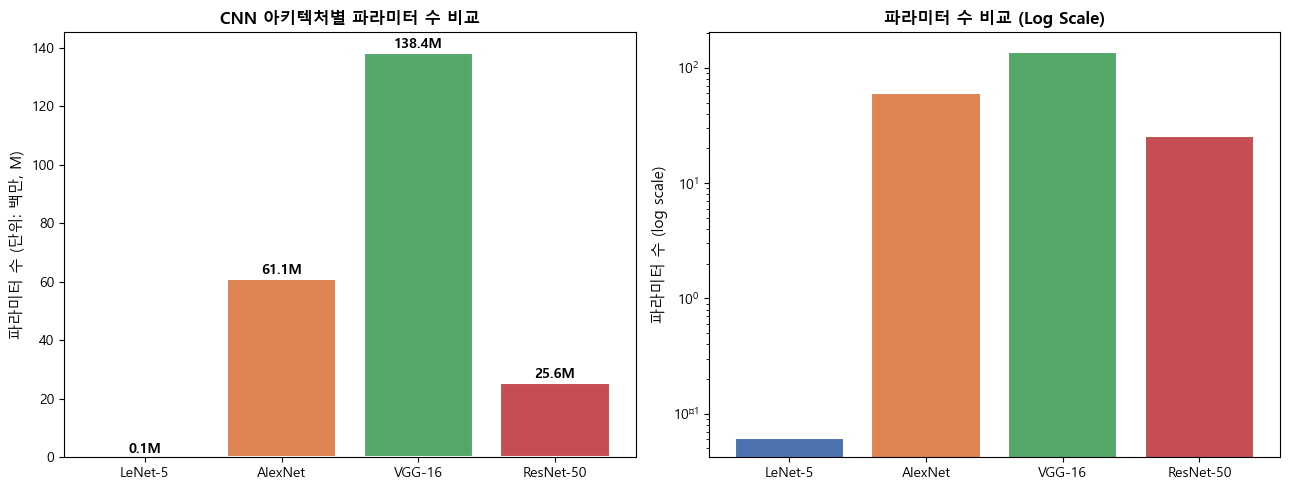


💡 관찰 포인트:
  - ResNet-50(25.6M)은 VGG-16(138.4M)보다 파라미터가 적지만 성능은 더 높습니다
  - VGG-16의 FC 레이어가 전체 파라미터의 약 87%를 차지합니다


In [11]:
# ─────────────────────────────────────────────
# 3-2. 파라미터 수 시각화 (막대 그래프)
# ─────────────────────────────────────────────

names = list(model_list.keys())
param_counts = [count_params(m)[0] / 1e6 for m in model_list.values()]  # 단위: M

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 막대 그래프
bars = axes[0].bar(names, param_counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel("파라미터 수 (단위: 백만, M)", fontsize=11)
axes[0].set_title("CNN 아키텍처별 파라미터 수 비교", fontsize=12, fontweight='bold')
for bar, val in zip(bars, param_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}M", ha='center', va='bottom', fontweight='bold')

# 로그 스케일 막대 그래프 (LeNet과 ResNet 차이 강조)
axes[1].bar(names, param_counts, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_ylabel("파라미터 수 (log scale)", fontsize=11)
axes[1].set_title("파라미터 수 비교 (Log Scale)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('architecture_params.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 관찰 포인트:")
print(f"  - ResNet-50({param_counts[3]:.1f}M)은 VGG-16({param_counts[2]:.1f}M)보다 파라미터가 적지만 성능은 더 높습니다")
print(f"  - VGG-16의 FC 레이어가 전체 파라미터의 약 87%를 차지합니다")

---
## 실습 4. ResidualBlock 직접 구현

ResNet의 핵심 아이디어인 Skip Connection을 직접 구현합니다.

> 🔑 **반드시 기억**: `output = F(x) + x` — 이 한 줄이 Vanishing Gradient 문제를 해결합니다.

### ✏️ TODO: ResidualBlock 구현

Shortcut connection(skip connection)을 포함한 ResidualBlock을 구현하세요.  
입출력 채널이 다를 때를 위한 `downsample` 처리도 포함해야 합니다.

In [ ]:
# ─────────────────────────────────────────────
# TODO: ResidualBlock 구현
# ─────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """
    ResNet의 기본 빌딩 블록 (ResNet-18, 34용).

    구조: Conv→BN→ReLU→Conv→BN + skip → ReLU
    입출력 채널이 다를 경우 1×1 Conv로 채널을 맞춥니다.

    Args:
        in_channels  (int): 입력 채널 수
        out_channels (int): 출력 채널 수
        stride       (int): 첫 번째 Conv의 스트라이드 (기본값: 1)
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # 메인 경로
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut 경로 (채널 수나 크기가 다를 때 맞춰주는 1×1 Conv)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x   # skip connection용 입력 보존

        # 메인 경로
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Shortcut 경로 (채널/크기 불일치 시 1×1 Conv 적용)
        if self.downsample is not None:
            identity = ___(x)  # 힌트: self.downsample을 x에 적용하세요

        # ✏️ 핵심: Skip connection — 메인 경로 출력 + 입력 더하기
        out = out + ___         # 힌트: identity를 더하세요

        out = F.relu(out)
        return out

print("ResidualBlock을 구현한 뒤 다음 셀을 실행하세요!")

In [12]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------

class ResidualBlock(nn.Module):
    """
    ResNet의 기본 빌딩 블록 (ResNet-18, 34용).

    Args:
        in_channels  (int): 입력 채널 수
        out_channels (int): 출력 채널 수
        stride       (int): 첫 번째 Conv의 스트라이드 (기본값: 1)
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity
        out = F.relu(out)
        return out

print("✅ ResidualBlock 정답 로드 완료!")

✅ ResidualBlock 정답 로드 완료!


In [13]:
# ─────────────────────────────────────────────
# 4-1. ResidualBlock forward pass 검증
# ─────────────────────────────────────────────

# 케이스 1: 채널 수 동일 (downsample 없음)
block_same = ResidualBlock(64, 64, stride=1)
x1 = torch.randn(2, 64, 32, 32)
out1 = block_same(x1)
print(f"케이스 1 (동일 채널): 입력 {x1.shape} → 출력 {out1.shape}")
assert out1.shape == x1.shape

# 케이스 2: 채널 수 다름 (downsample 필요)
block_diff = ResidualBlock(64, 128, stride=2)
x2 = torch.randn(2, 64, 32, 32)
out2 = block_diff(x2)
print(f"케이스 2 (채널 확장): 입력 {x2.shape} → 출력 {out2.shape}")
assert out2.shape == (2, 128, 16, 16)

print("\n✅ 두 케이스 모두 통과! ResidualBlock 구현 정확합니다 🎉")

케이스 1 (동일 채널): 입력 torch.Size([2, 64, 32, 32]) → 출력 torch.Size([2, 64, 32, 32])
케이스 2 (채널 확장): 입력 torch.Size([2, 64, 32, 32]) → 출력 torch.Size([2, 128, 16, 16])

✅ 두 케이스 모두 통과! ResidualBlock 구현 정확합니다 🎉


---
## 실습 5. Skip Connection의 효과 — Gradient 흐름 비교

In [14]:
# ─────────────────────────────────────────────
# 5-1. Skip Connection 유무에 따른 Gradient 크기 비교
# ─────────────────────────────────────────────

# 일반 블록 (skip connection 없음)
class PlainBlock(nn.Module):
    """Skip connection 없는 일반 블록 (비교용)."""
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return F.relu(self.net(x))

# 깊은 네트워크 구성 (10 블록)
N_BLOCKS = 10

plain_net = nn.Sequential(*[PlainBlock(32) for _ in range(N_BLOCKS)])
res_net   = nn.Sequential(*[ResidualBlock(32, 32) for _ in range(N_BLOCKS)])

x = torch.randn(2, 32, 16, 16)
loss_plain = plain_net(x).mean()
loss_res   = res_net(x).mean()

loss_plain.backward()
loss_res.backward()

# 각 모델의 첫 번째 블록 conv1 gradient norm
grad_plain = plain_net[0].net[0].weight.grad.norm().item()
grad_res   = res_net[0].conv1.weight.grad.norm().item()

print("=== 10개 블록 통과 후 첫 번째 레이어 Gradient 크기 ===")
print(f"  일반 네트워크 (Plain):    {grad_plain:.6f}")
print(f"  Residual 네트워크:        {grad_res:.6f}")
print(f"\n  → Residual이 {grad_res/max(grad_plain,1e-10):.1f}배 큰 gradient 유지")
print("  → Skip connection이 gradient를 보존합니다 ✅")

=== 10개 블록 통과 후 첫 번째 레이어 Gradient 크기 ===
  일반 네트워크 (Plain):    2.569510
  Residual 네트워크:        0.662103

  → Residual이 0.3배 큰 gradient 유지
  → Skip connection이 gradient를 보존합니다 ✅


---
## 실습 6. 전체 아키텍처 Forward Pass 비교

In [15]:
# ─────────────────────────────────────────────
# 6-1. 동일 더미 입력으로 4개 모델 통과
# ─────────────────────────────────────────────

# ImageNet 표준 입력 (224×224 RGB, 배치 2)
dummy_224 = torch.randn(2, 3, 224, 224)
# LeNet은 (32×32 흑백) 사용
dummy_lenet = torch.randn(2, 1, 32, 32)

results = {}
with torch.no_grad():
    results["LeNet-5"]   = lenet(dummy_lenet)
    results["AlexNet"]   = alexnet(dummy_224)
    results["VGG-16"]    = vgg16(dummy_224)
    results["ResNet-50"] = resnet50(dummy_224)

print(f"{'모델':<12} {'입력 shape':<20} {'출력 shape':<15}")
print("-" * 50)
inputs = {"LeNet-5": dummy_lenet, "AlexNet": dummy_224,
          "VGG-16": dummy_224, "ResNet-50": dummy_224}
for name, out in results.items():
    print(f"{name:<12} {str(inputs[name].shape):<20} {str(out.shape):<15}")

print("\n✅ 모든 모델 Forward pass 성공!")

모델           입력 shape             출력 shape       
--------------------------------------------------
LeNet-5      torch.Size([2, 1, 32, 32]) torch.Size([2, 10])
AlexNet      torch.Size([2, 3, 224, 224]) torch.Size([2, 1000])
VGG-16       torch.Size([2, 3, 224, 224]) torch.Size([2, 1000])
ResNet-50    torch.Size([2, 3, 224, 224]) torch.Size([2, 1000])

✅ 모든 모델 Forward pass 성공!


In [ ]:
# ─────────────────────────────────────────────
# 6-2. ✏️ 빈칸: ResNet-50 레이어별 출력 크기 추적
# ─────────────────────────────────────────────

x = torch.randn(1, 3, 224, 224)
print(f"입력: {x.shape}")

with torch.no_grad():
    # ResNet-50의 초기 레이어 순서대로 통과
    x = resnet50.conv1(x)
    print(f"conv1 후:    {x.shape}")

    x = resnet50.bn1(x)
    x = resnet50.relu(x)
    x = resnet50.maxpool(x)
    print(f"maxpool 후:  {x.shape}")

    x = resnet50.layer1(x);  print(f"layer1 후:   {x.shape}")
    x = resnet50.layer2(x);  print(f"layer2 후:   {x.shape}")
    x = resnet50.layer3(x);  print(f"layer3 후:   {x.shape}")
    x = resnet50.layer4(x);  print(f"layer4 후:   {x.shape}")

    # ✏️ Global Average Pooling 적용
    x = ___(x)               # 힌트: resnet50.avgpool을 적용하세요
    print(f"avgpool 후:  {x.shape}")

    x = torch.flatten(x, 1)
    print(f"flatten 후:  {x.shape}")

    x = resnet50.fc(x)
    print(f"fc 후:       {x.shape}")

입력: torch.Size([1, 3, 224, 224])
conv1 후:    torch.Size([1, 64, 112, 112])
maxpool 후:  torch.Size([1, 64, 56, 56])
layer1 후:   torch.Size([1, 256, 56, 56])
layer2 후:   torch.Size([1, 512, 28, 28])
layer3 후:   torch.Size([1, 1024, 14, 14])
layer4 후:   torch.Size([1, 2048, 7, 7])
avgpool 후:  torch.Size([1, 2048, 1, 1])
flatten 후:  torch.Size([1, 2048])
fc 후:       torch.Size([1, 1000])


In [ ]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# x = resnet50.avgpool(x)
# → Global Average Pooling: (1,2048,7,7) → (1,2048,1,1)

---
## 🚀 도전 과제

### 과제 1. Bottleneck Block 구현
ResNet-50에서 사용하는 Bottleneck Block을 구현하세요.  
구조: `1×1 Conv(채널 축소) → 3×3 Conv → 1×1 Conv(채널 복원) + skip`

```python
class BottleneckBlock(nn.Module):
    expansion = 4  # 출력 채널 = mid_channels * expansion

    def __init__(self, in_channels, mid_channels, stride=1):
        ...
```

### 과제 2. 파라미터 효율성 분석
`VGG-16`의 `features`와 `classifier` 각각의 파라미터 수를 계산하고,  
전체 파라미터 중 FC 레이어가 차지하는 비율을 출력하세요.

### 과제 3. torchinfo로 모델 요약
```bash
pip install torchinfo
```
`torchinfo.summary(resnet50, input_size=(1, 3, 224, 224))`로 레이어별 출력 크기와  
FLOPs(연산량)를 확인하고, LeNet-5와 비교하세요.
